# Evaluate ranges of output dataset
Diagnostics comparing our downscaled data against the ranges from ERA5. Rather than hard-and-fast checks for aphysical values (e.g. negative precip), this checks for squishier situations like is there a high precipitation event in the Sahara. Goal is to surface problems. 

In [1]:
import math

import boto3
import icechunk
import matplotlib.pyplot as plt
import xarray as xr
from srm.utils import resolve_s3_glob, open_icechunk
from srm import catalog
from dask.distributed import Client
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://cluster-xoxzh.dask.host/jupyter/proxy/8787/status,
Dashboard: https://cluster-xoxzh.dask.host/jupyter/proxy/8787/status,Workers: 8
Total threads: 64,Total memory: 244.51 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39227,Workers: 0
Dashboard: https://cluster-xoxzh.dask.host/jupyter/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38775,Total threads: 8
Dashboard: https://cluster-xoxzh.dask.host/jupyter/proxy/41439/status,Memory: 30.56 GiB
Nanny: tcp://127.0.0.1:34141,


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xff8d8b13c050>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xff8d8b0ddb00>, 168.73982419)])']
connector: <aiohttp.connector.TCPConnector object at 0xff8d8c46fc50>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xff8d8b13ec10>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xff8d8b0dd8d0>, 168.741908452)])']
connector: <aiohttp.connector.TCPConnector object at 0xff8d8b13e710>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xff8d8b13e490>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xff8d8b0ddd30>, 168.747293771)])']
connector: <aiohttp.connector.TCPConnector object at 0xff8d8b13c2d0>


In [19]:
def get_fname(var, scenario, version="test015_benchmark", ens="003"):
    fname = (
        "s3://carbonplan-scratch/srm/output/qa/"
        + version
        + "/"
        + scenario
        + "/CESM2-WACCM/"
        + var
        + "/"
        + ens
        + "/global/era5/*/"
        + scenario
        + ".icechunk/"
    )

    return fname

In [4]:
_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Grey for zero, continuous Reds for positive values
_EXCEEDANCE_CMAP = plt.cm.Reds.copy()
_EXCEEDANCE_CMAP.set_under("lightgrey")


def calc_era5_threshold(era5, var, direction, period="annual", downscaled_da=None):
    """Per-pixel ERA5 threshold: 'gt' → max, 'lt' → min; 'monthly' groups by calendar month."""
    if downscaled_da is not None:
        era5_da = era5[var].sel(lat=downscaled_da.lat, lon=downscaled_da.lon, method="nearest")
    else:
        era5_da = era5[var]
    if period == "annual":
        if direction == "gt":
            return era5_da.max(dim="time").load()
        elif direction == "lt":
            return era5_da.min(dim="time").load()
    elif period == "monthly":
        if direction == "gt":
            return era5_da.groupby("time.month").max(dim="time").load()
        elif direction == "lt":
            return era5_da.groupby("time.month").min(dim="time").load()


def count_exceedances(downscaled_da, threshold, direction, period="annual"):
    """Annual: (lat, lon) count over all time. Monthly: (month, lat, lon) count per calendar month."""
    if period == "annual":
        if direction == "gt":
            return (downscaled_da > threshold).sum(dim="time").load()
        return (downscaled_da < threshold).sum(dim="time").load()
    counts = []
    for m, group in downscaled_da.groupby("time.month"):
        thresh = threshold.sel(month=m)
        exceeded = group > thresh if direction == "gt" else group < thresh
        counts.append(exceeded.sum("time").expand_dims(month=[m]))
    return xr.concat(counts, dim="month").load()


def plot_exceedance_map(count_da, title, period="annual", var_lims=None):
    """Single panel for annual; 3×4 panel for monthly (one per calendar month)."""
    # vmin=0.5 pushes exactly-zero cells below the colormap range → rendered as lightgrey
    vmin = 0.5 if var_lims is None else max(var_lims[0], 0.5)
    vmax = None if var_lims is None else var_lims[1]

    def _plot_panel(da, ax):
        da.plot(
            ax=ax,
            cmap=_EXCEEDANCE_CMAP,
            vmin=vmin,
            vmax=vmax,
            transform=ccrs.PlateCarree(),
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    if period == "annual":
        fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(projection=ccrs.PlateCarree()))
        _plot_panel(count_da, ax)
        ax.set_title(title)
        plt.tight_layout()
        plt.show()
    elif period == "monthly":
        fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(24, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))
        fig.suptitle(title, fontsize=12)
        for i, ax in enumerate(axs.flatten()):
            m = i + 1
            _plot_panel(count_da.sel(month=m), ax)
            ax.set_title(_MONTH_NAMES[i])
        plt.tight_layout()
        plt.show()

In [5]:
# Each entry is var: [(direction, period, title)]
checks_dict ={"tasmax": [("gt", "annual",  "Greater than ERA5 annual max tasmax"),
                ("gt", "monthly", "Greater than ERA5 monthly max tasmax")       ],
    "tasmin": [("lt", "annual",  "Less than ERA5 annual min tasmin"),
                ("lt", "monthly", "Less than ERA5 monthly min tasmin")],
   "tas": [("gt", "annual",  "Greater than ERA5 annual max tasmean"),
            ("lt", "annual",  "Less than ERA5 annual min tasmean")],
    "pr": [("gt", "monthly", "Greater than ERA5 monthly max precipitation"),
            ("gt", "annual",  "Greater than ERA5 annual max precipitation")],
    "rsds": [("gt", "annual",  "Greater than ERA5 annual max rsds")],
   "hurs": [("lt", "annual",  "Less than ERA5 annual min relative humidity")]
    }

In [6]:
recalculate_era5_stats = False
if recalculate_era5_stats:
    era5 = catalog.get("ERA5").to_xarray()
    era5_stats_ds = xr.Dataset()
    for var, direction, period, title in checks:
        era5_stats_ds["-".join([var, direction, period])] = calc_era5_threshold(era5, var, direction, period=period)
        
        era5_stats_ds.to_zarr("s3://carbonplan-scratch/srm/output/qa/era5_stats.zarr", mode="w")
else:
    era5_stats_ds = xr.open_zarr("s3://carbonplan-scratch/srm/output/qa/era5_stats.zarr")

In [8]:
version = "nonparametric_qa"

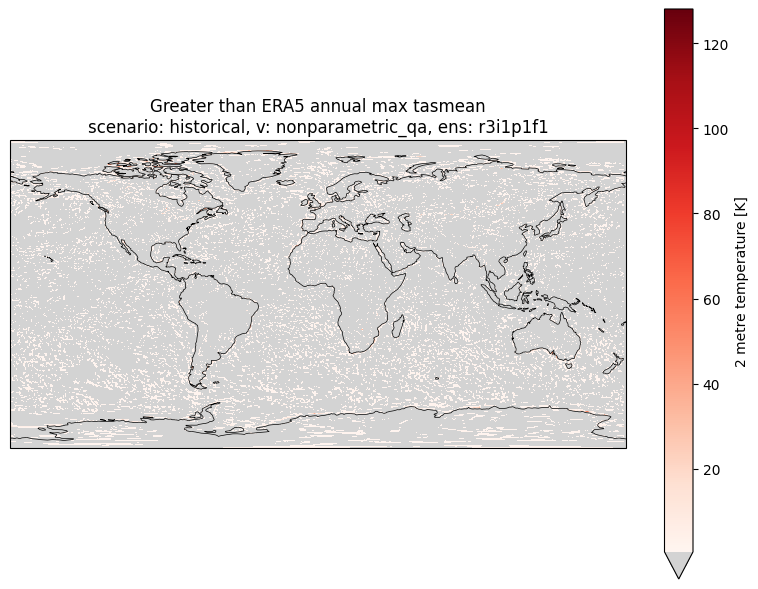

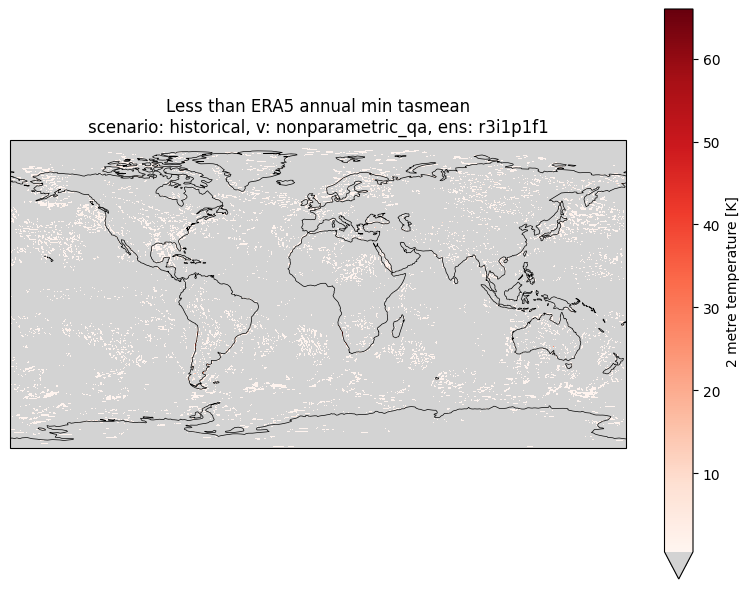

/opt/coiled/env/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 59.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


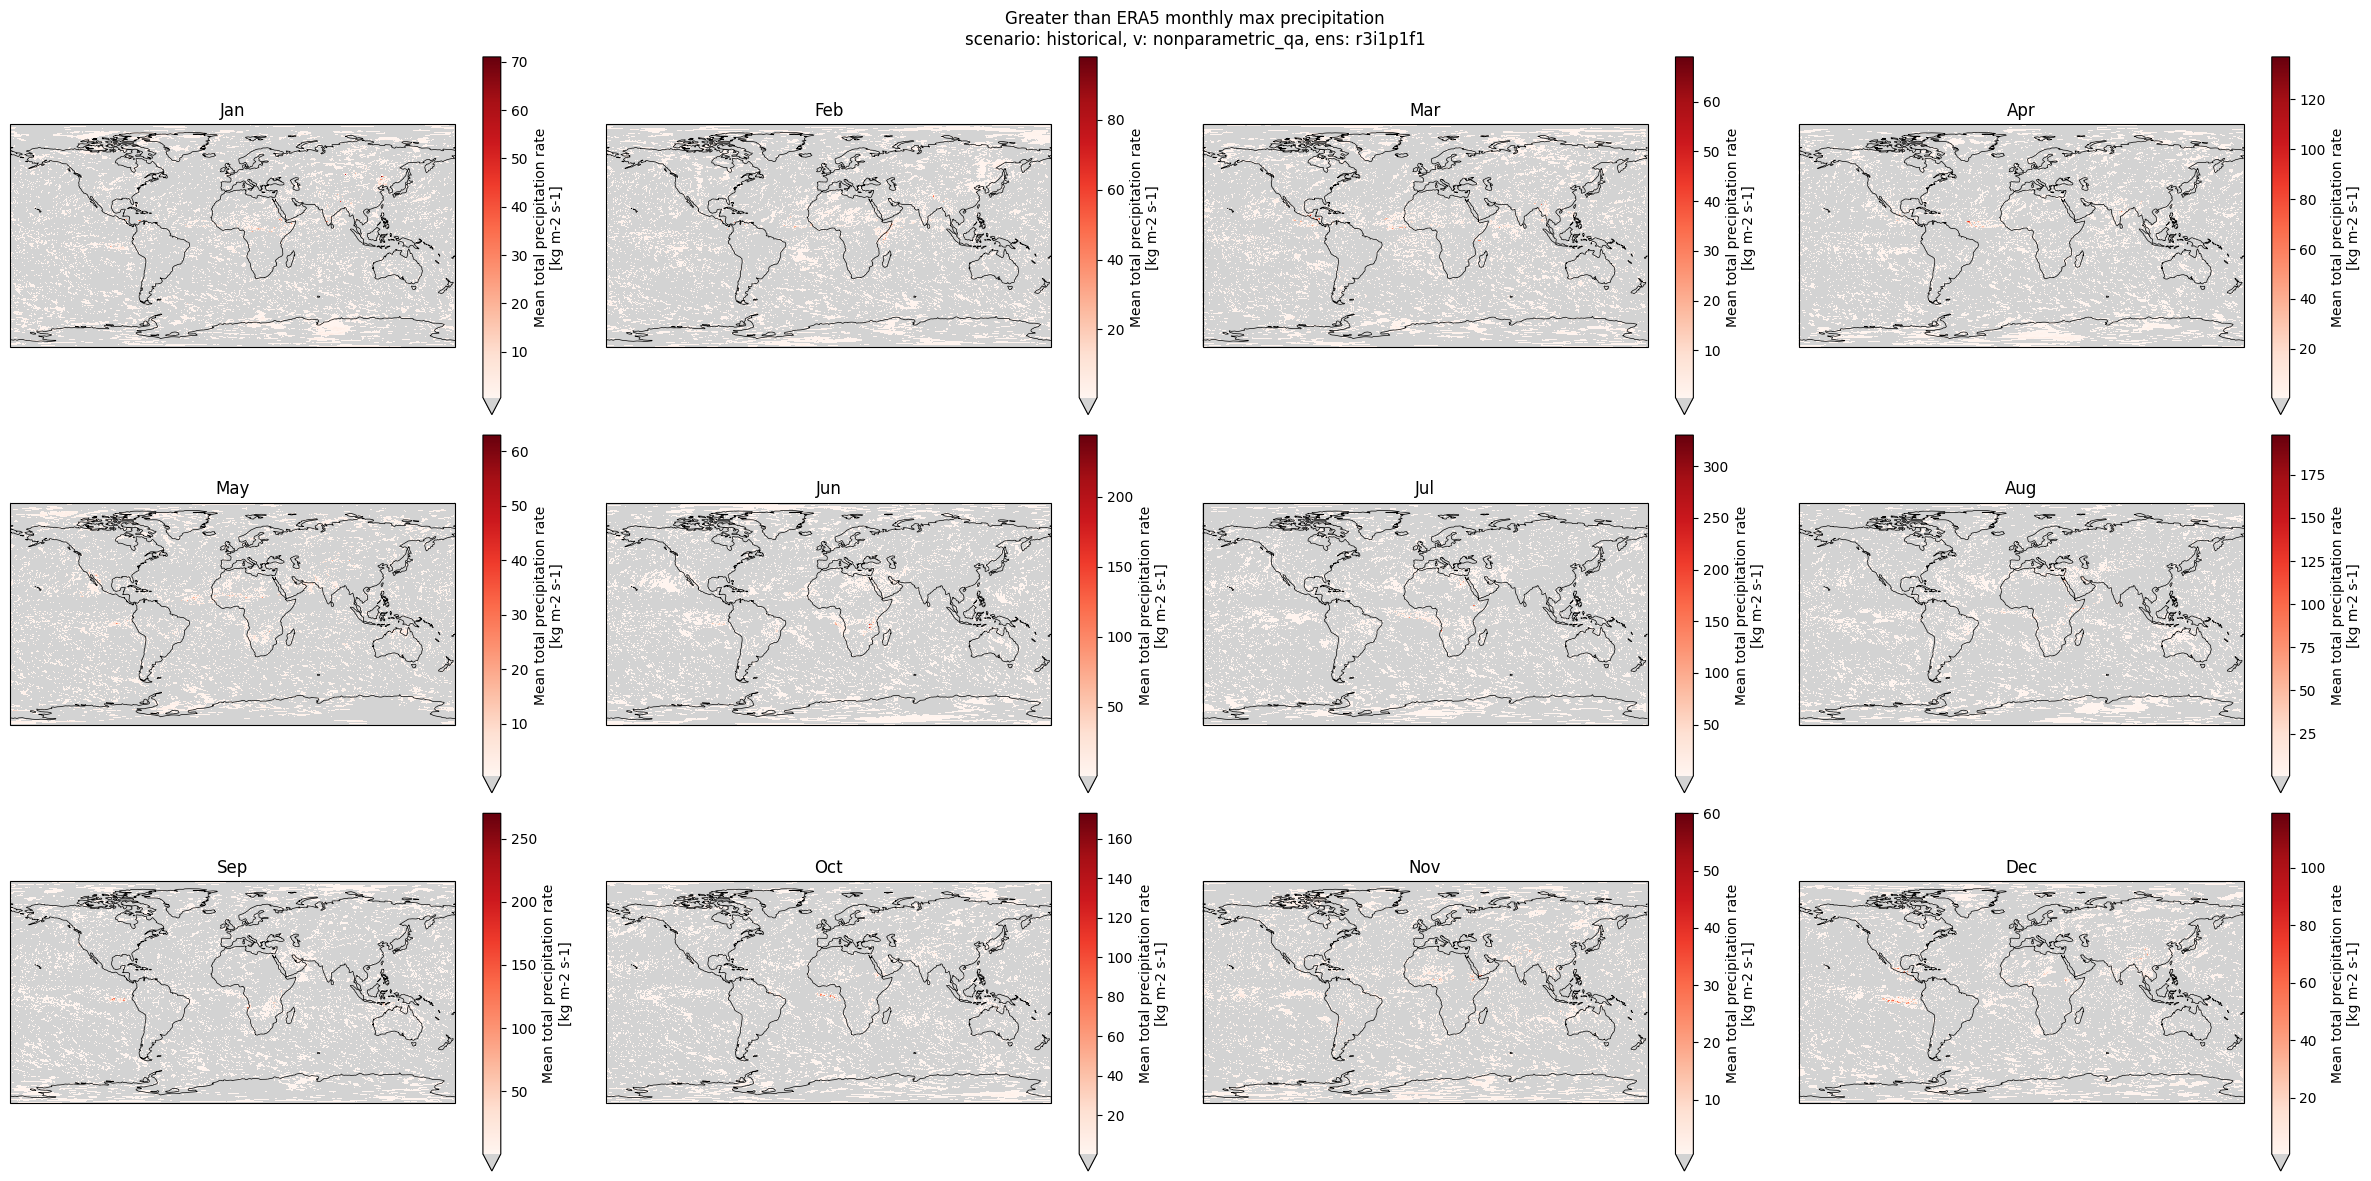

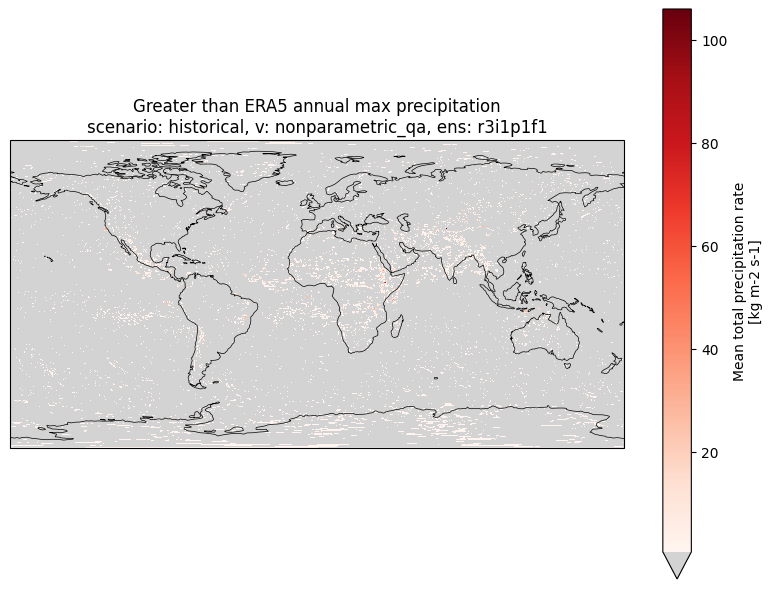

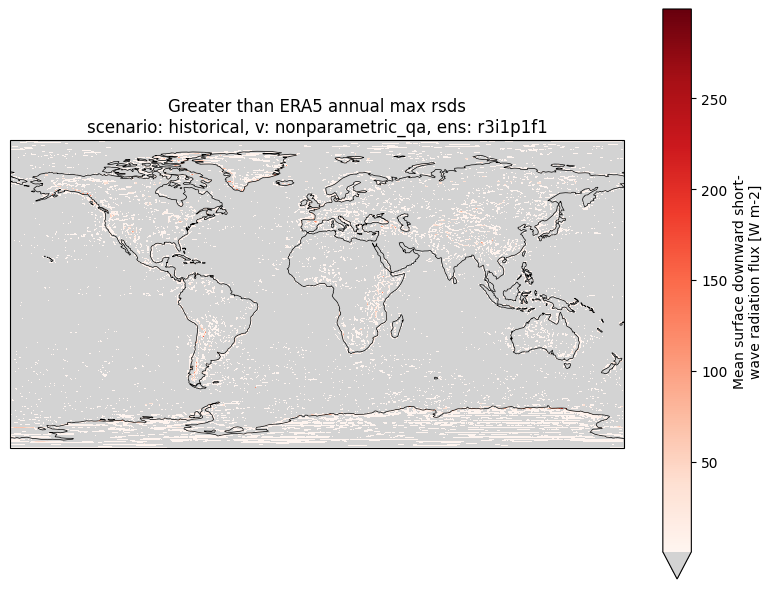

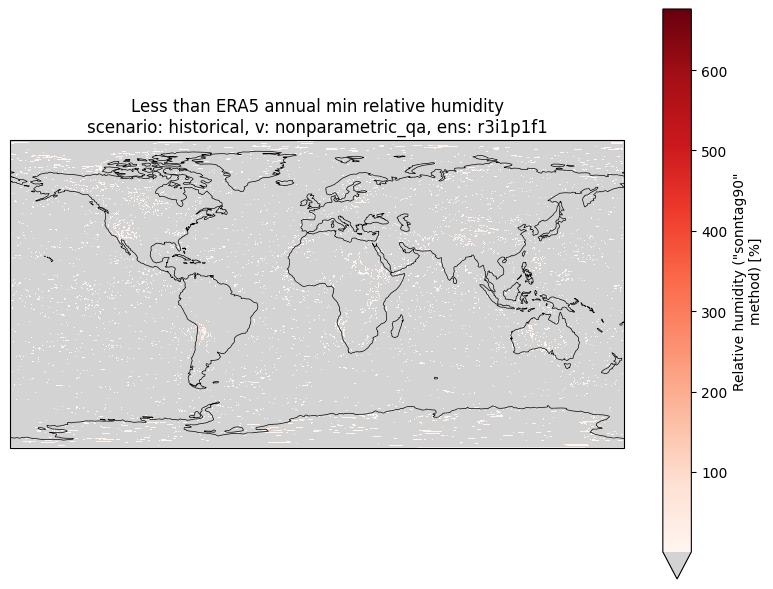

In [7]:
setups = [
    ("historical", "r3i1p1f1", ["tas", "pr", "rsds", "hurs"]),
    ]
for (scenario, ens, variables) in setups:
    for var in variables:
        checks = checks_dict[var]
        for direction, period, title in checks:
            fname = get_fname(var=var, scenario=scenario, version=version, ens=ens)
            fname = resolve_s3_glob(fname)
            downscaled_da = open_icechunk(path=fname)[var]
            threshold = era5_stats_ds["-".join([var, direction, period])]
            count = count_exceedances(downscaled_da, threshold, direction, period)
            plot_exceedance_map(count, title+f"\nscenario: {scenario}, v: {version}, ens: {ens}", period=period)

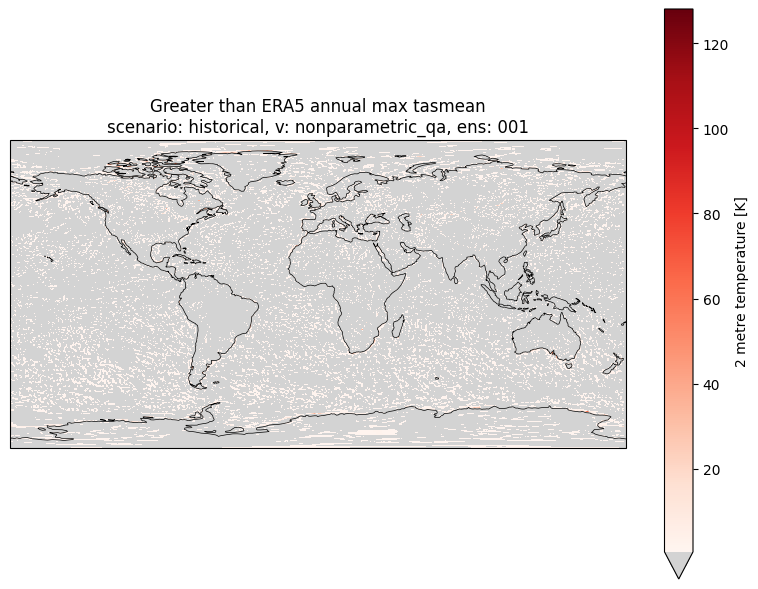

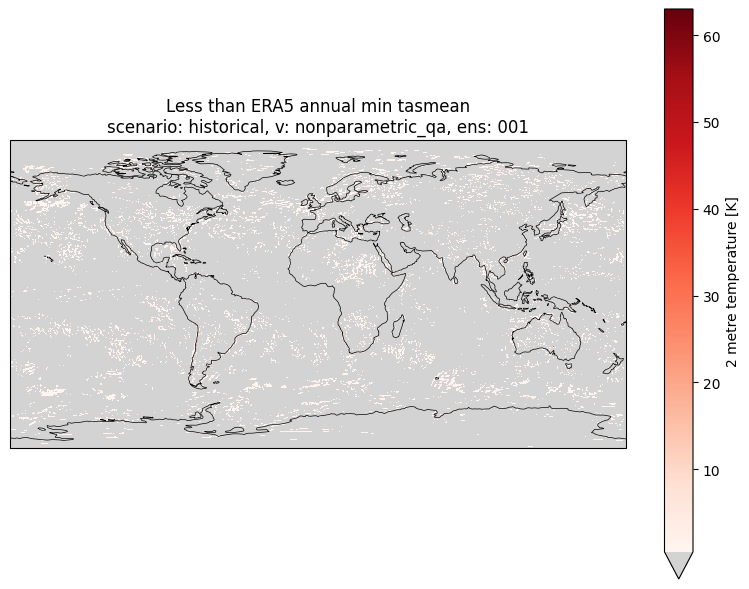

/opt/coiled/env/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 59.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


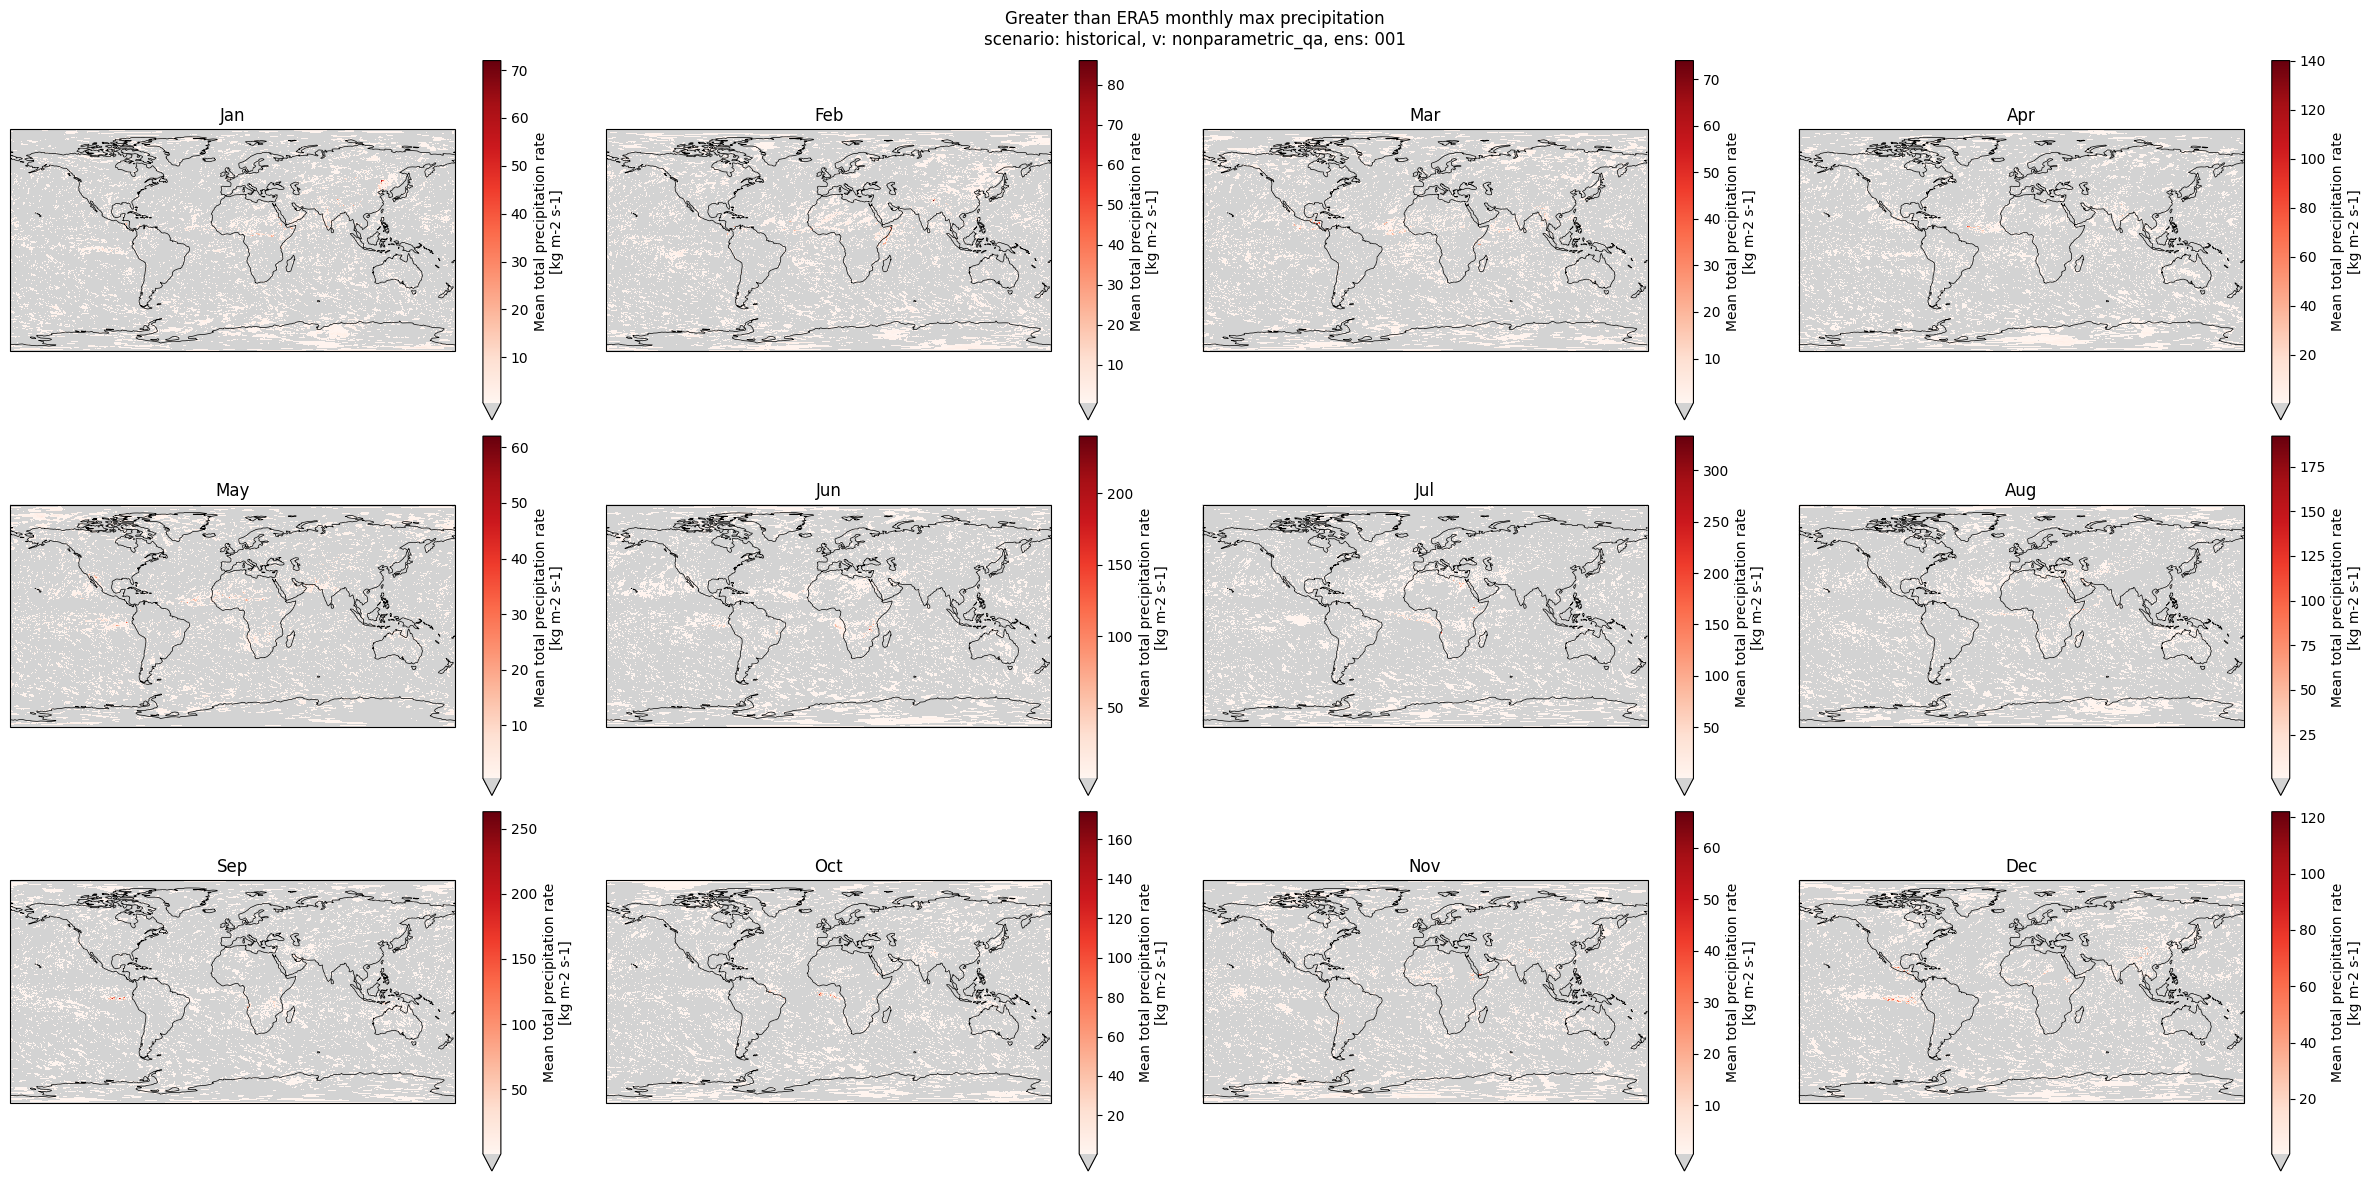

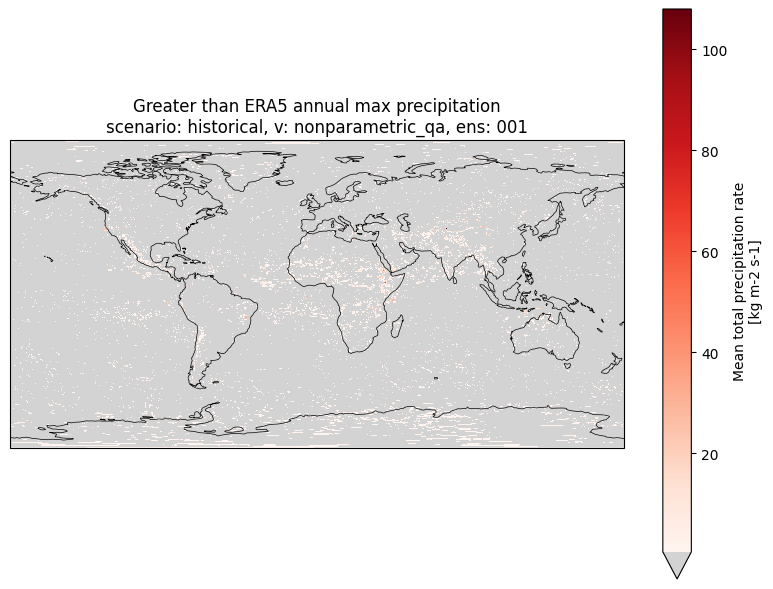

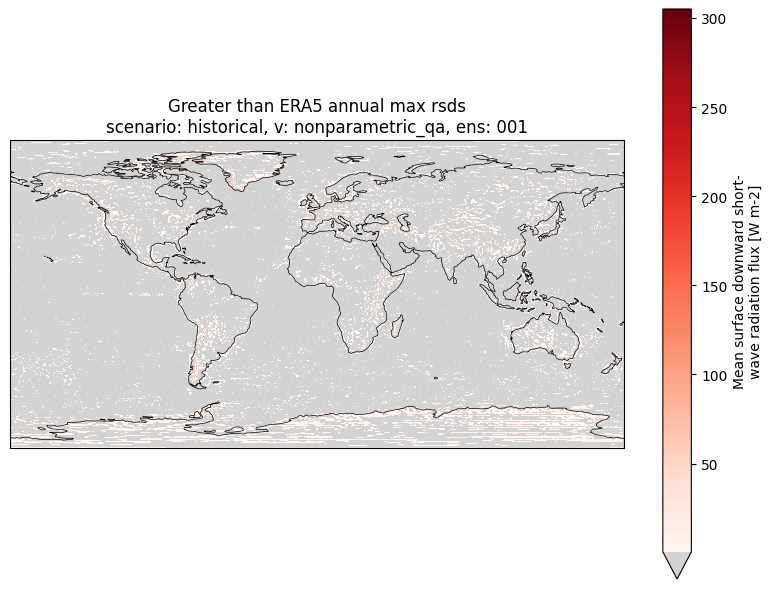

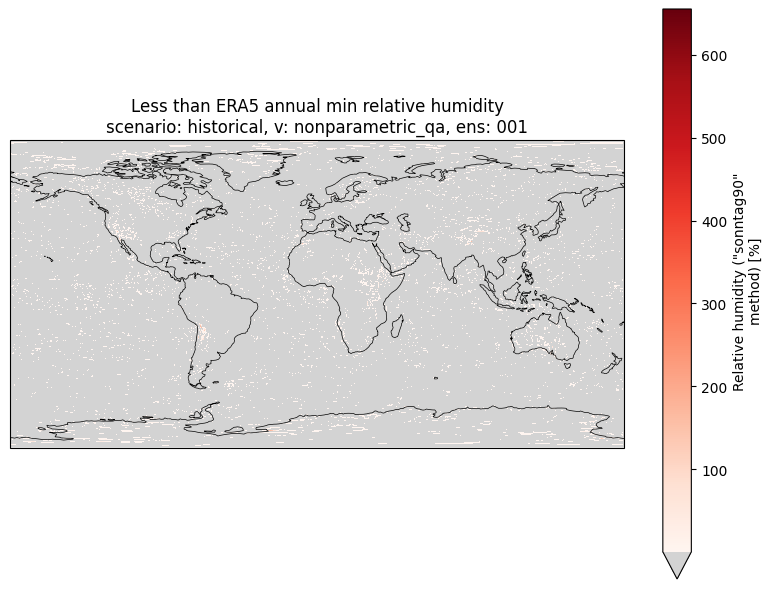

KeyError: "No variable named 'tasmax-lt-annual'. Did you mean one of ('tasmax-gt-annual', 'tas-lt-annual', 'tasmin-lt-annual', 'tas-gt-annual', 'hurs-lt-annual', 'tasmax-gt-monthly', 'rsds-gt-annual', 'pr-gt-annual', 'tasmin-lt-monthly')?"

In [8]:
setups = [("historical", "001", ["tas", "pr", "rsds", "hurs", "tasmax", "tasmin"]),
    ("g6-1.5K", "003", ["pr", "rsds", "hurs", "tasmax", "tasmin"]),
    ("ssp245", "003", ["tas", "pr", "rsds", "hurs"]),]
for (scenario, ens, variables) in setups:
    for var in variables:
        checks = checks_dict[var]
        for direction, period, title in checks:
            fname = get_fname(var=var, scenario=scenario, version=version, ens=ens)
            fname = resolve_s3_glob(fname)
            downscaled_da = open_icechunk(path=fname)[var]
            threshold = era5_stats_ds["-".join([var, direction, period])]
            count = count_exceedances(downscaled_da, threshold, direction, period)
            plot_exceedance_map(count, title+f"\nscenario: {scenario}, v: {version}, ens: {ens}", period=period)

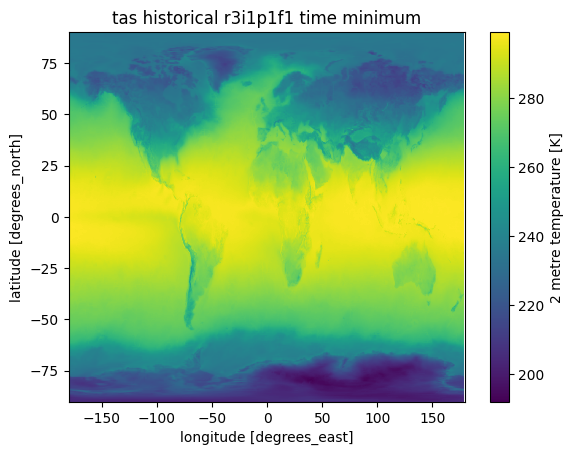

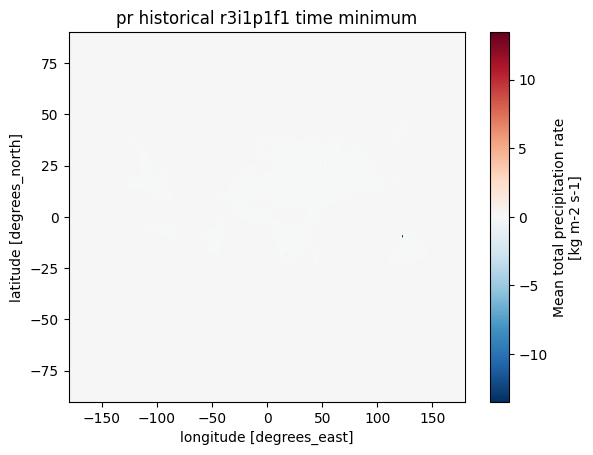

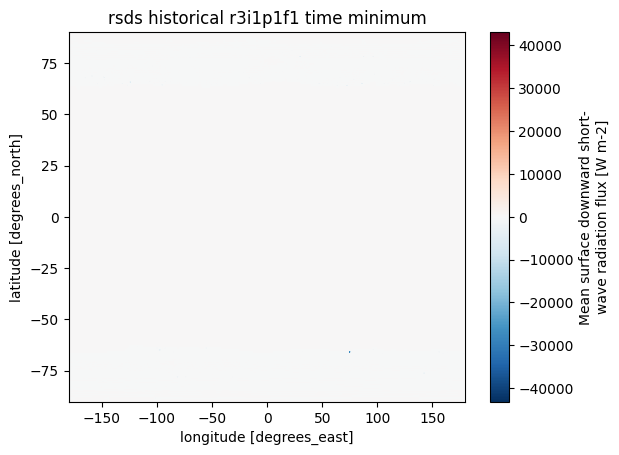

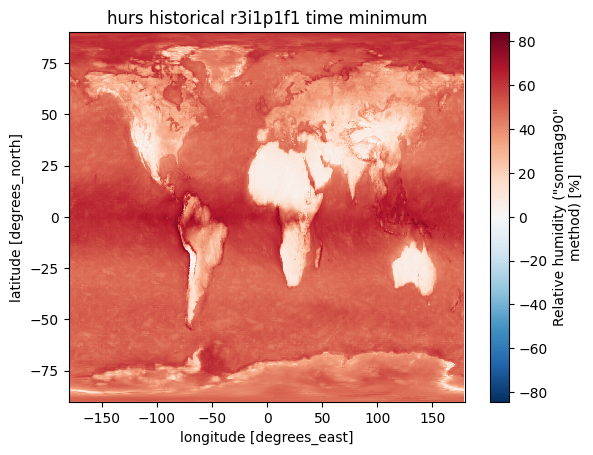

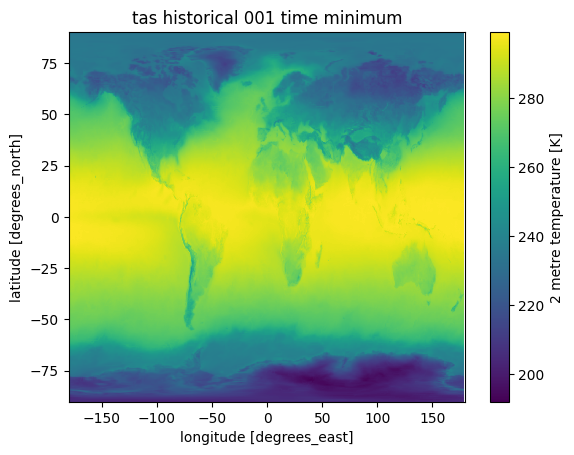

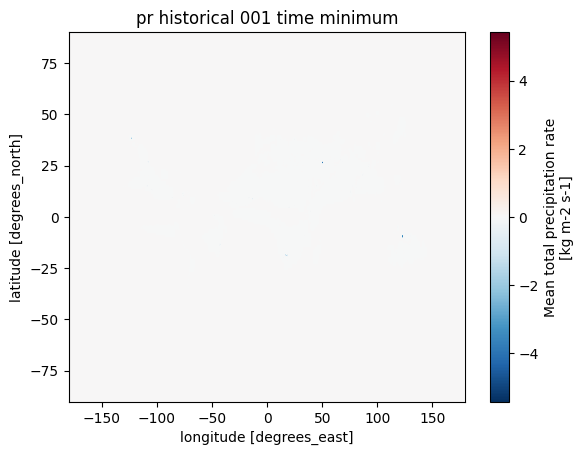

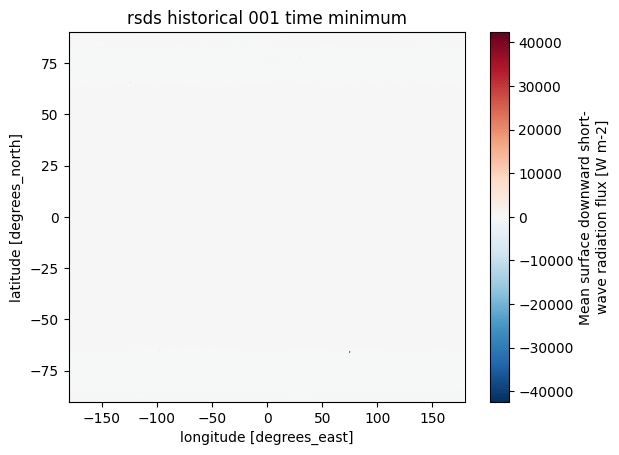

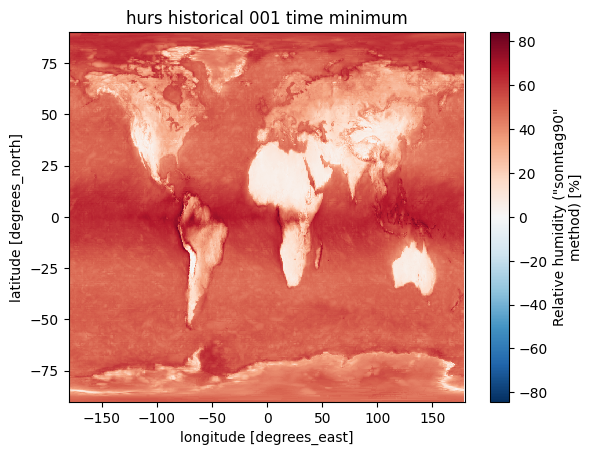

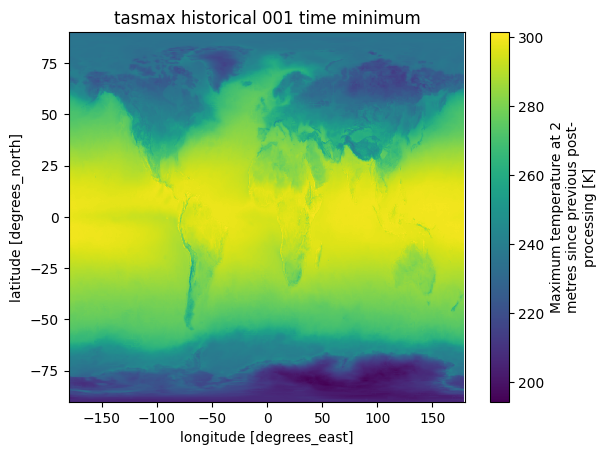

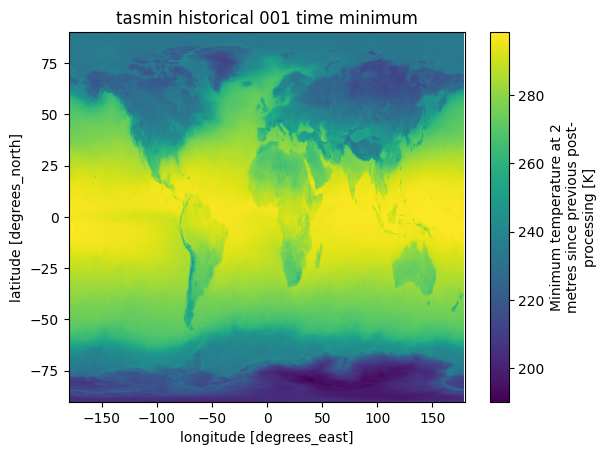

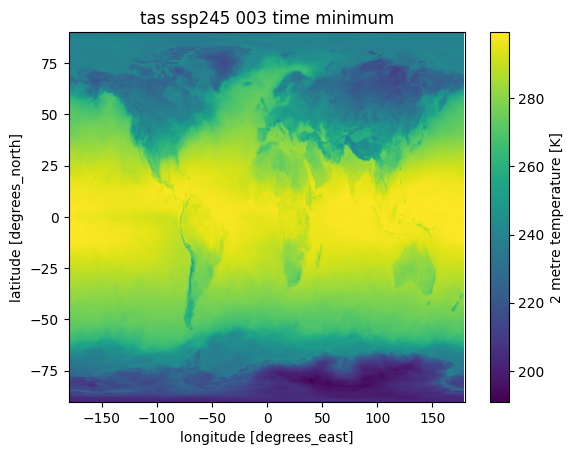

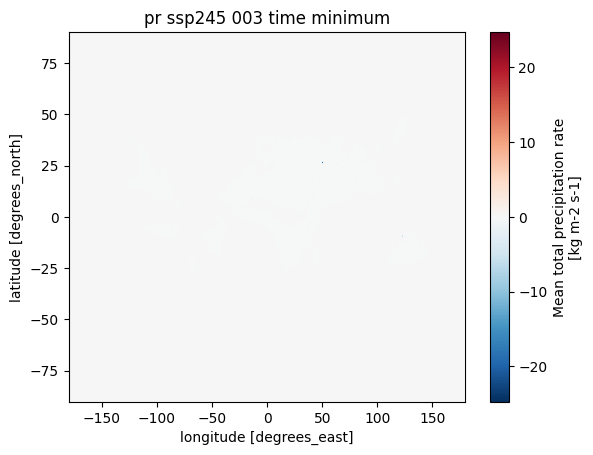

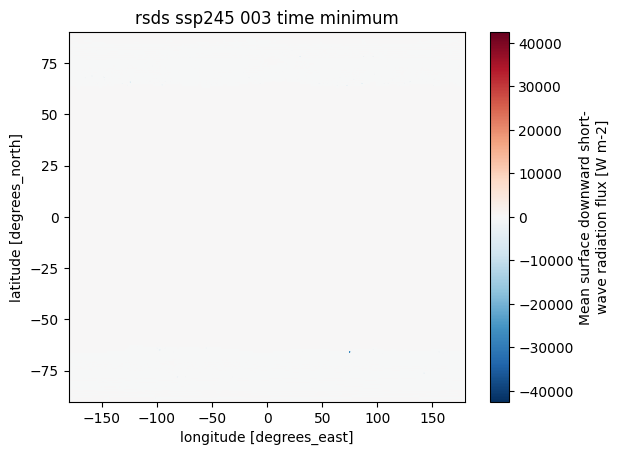

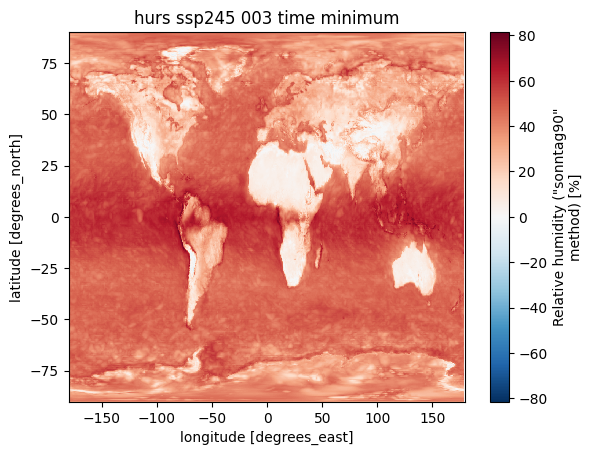

ValueError: No S3 paths matched: s3://carbonplan-scratch/srm/output/qa/nonparametric_qa/g6-1.5K/CESM2-WACCM/pr/003/global/era5/*/g6-1.5K.icechunk/

In [21]:
setups = [("historical", "r3i1p1f1", ["tas", "pr", "rsds", "hurs"]),
    ("historical", "001", ["tas", "pr", "rsds", "hurs", "tasmax", "tasmin"]),
          ("ssp245", "003", ["tas", "pr", "rsds", "hurs"]),
    ("g6-1.5K", "003", ["pr", "rsds", "hurs", "tasmax", "tasmin"]),
    ]
for (scenario, ens, variables) in setups:
    for var in variables:
        fname = get_fname(var=var, scenario=scenario, version=version, ens=ens)
        fname = resolve_s3_glob(fname)
        downscaled_da = open_icechunk(path=fname)[var]
        downscaled_da.min(dim='time').plot()
        plt.title(var+" "+scenario+" "+ens+ " time minimum" )
        plt.show()

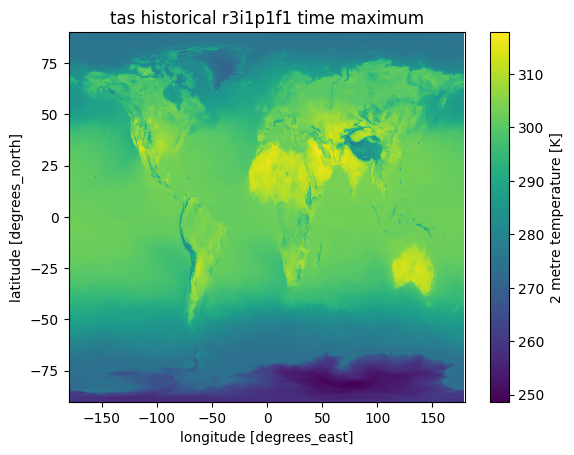

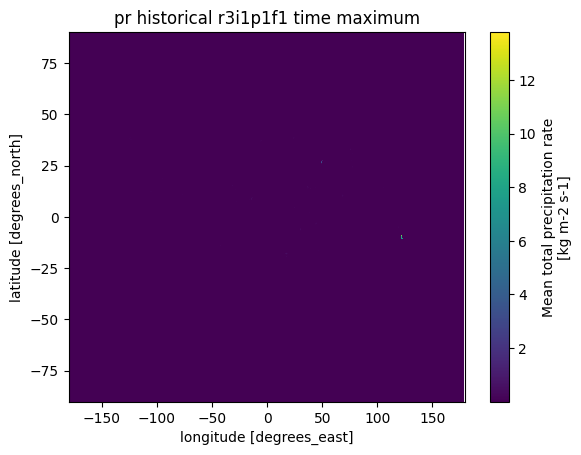

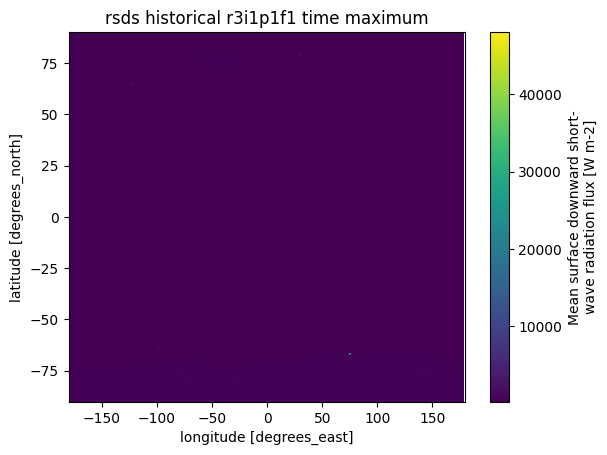

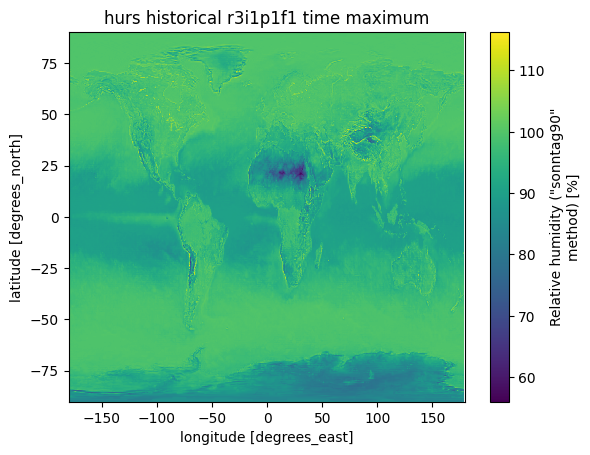

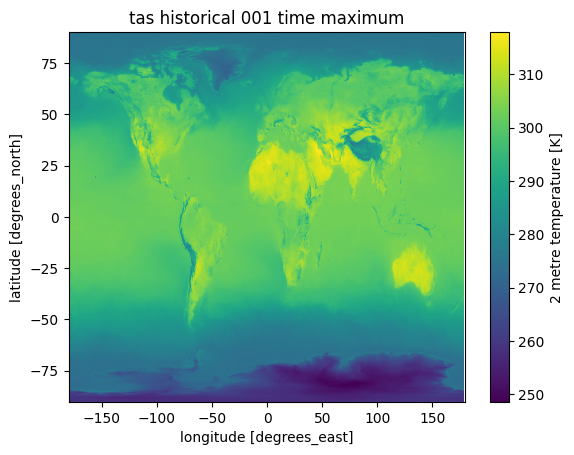

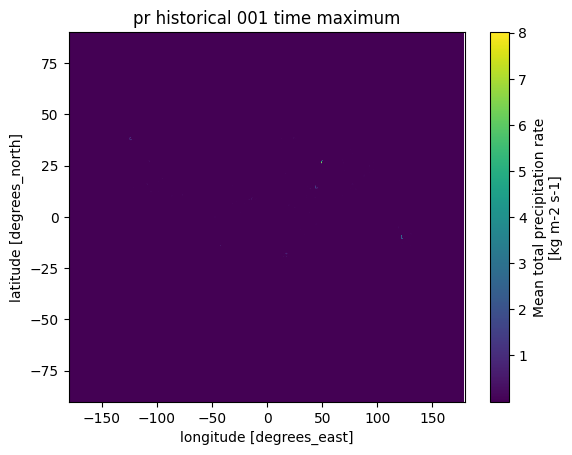

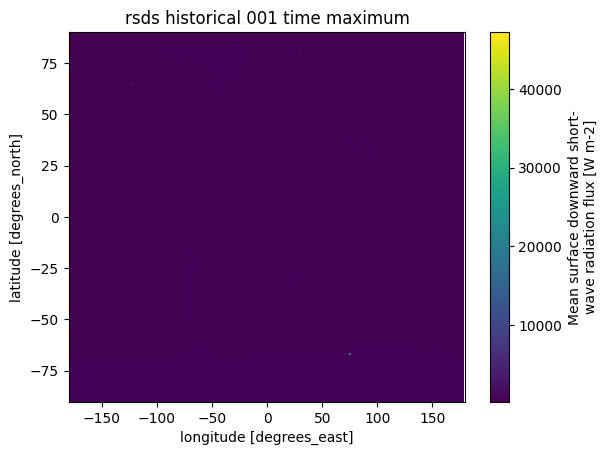

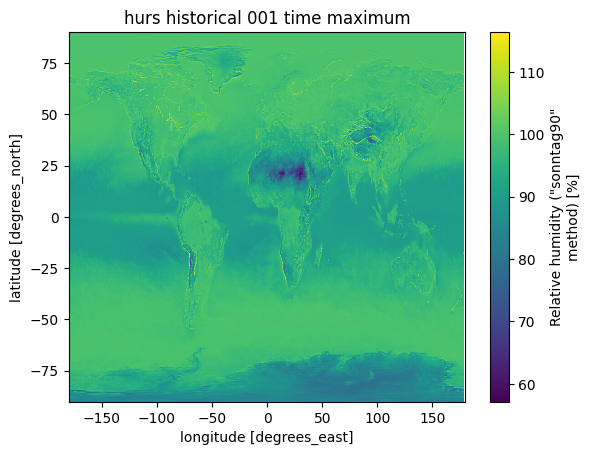

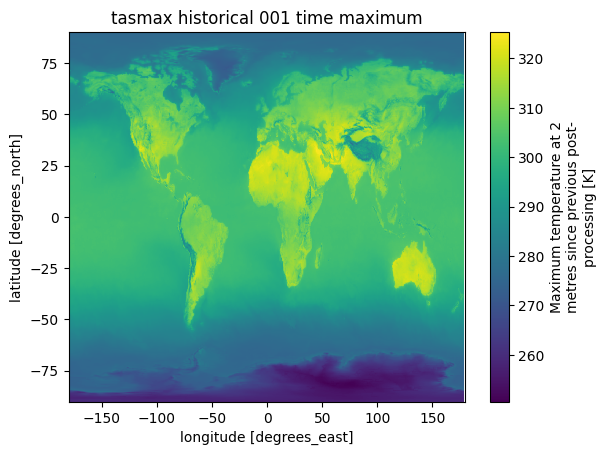

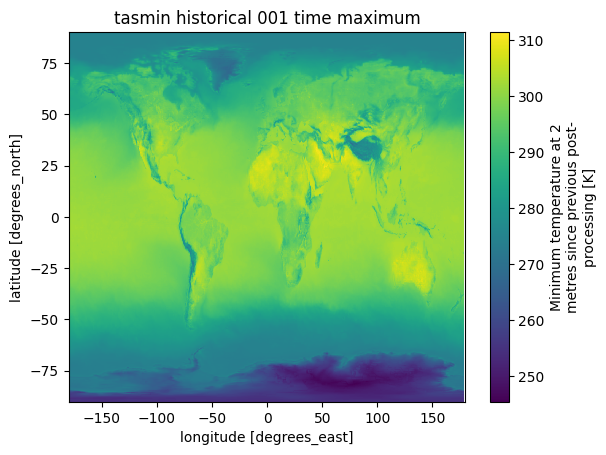

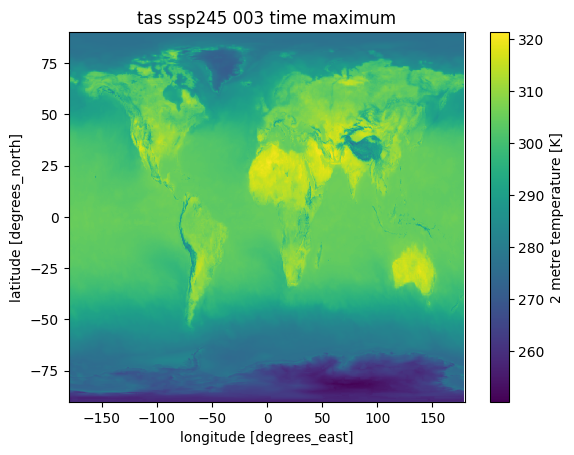

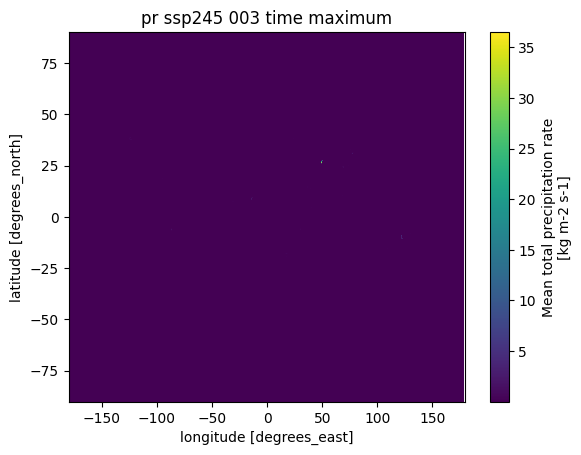

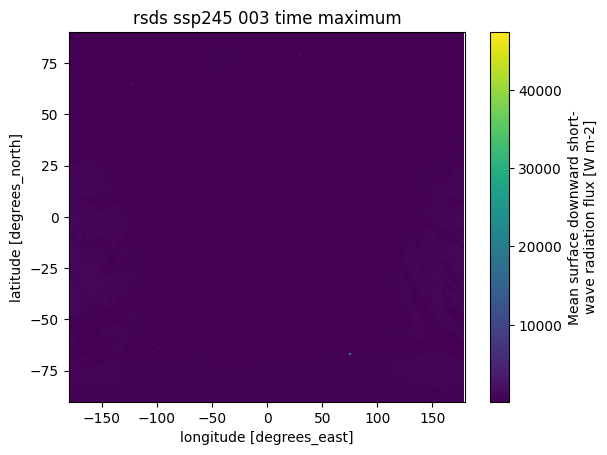

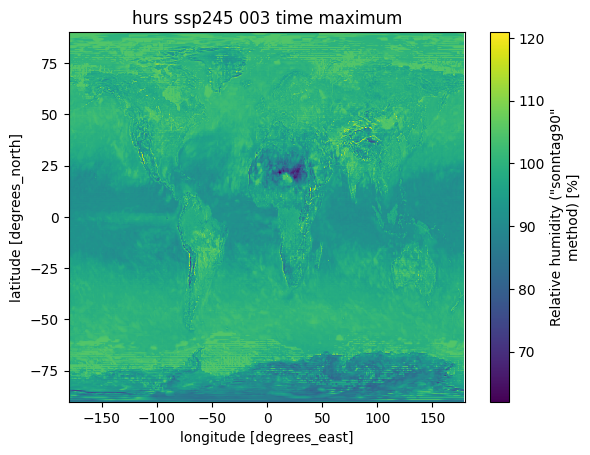

ValueError: No S3 paths matched: s3://carbonplan-scratch/srm/output/qa/nonparametric_qa/g6-1.5K/CESM2-WACCM/pr/003/global/era5/*/g6-1.5K.icechunk/

In [22]:
for (scenario, ens, variables) in setups:
    for var in variables:
        fname = get_fname(var=var, scenario=scenario, version=version, ens=ens)
        fname = resolve_s3_glob(fname)
        downscaled_da = open_icechunk(path=fname)[var]
        downscaled_da.max(dim='time').plot()
        plt.title(var+" "+scenario+" "+ens+ " time maximum" )
        plt.show()